OBTAINING DEMO DATA
DYNAMICAL SYSTEM TRAINING


/home/mahathi/Projects/neural/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


MSE of Initial Estimate of Dynamical System: 0.0032


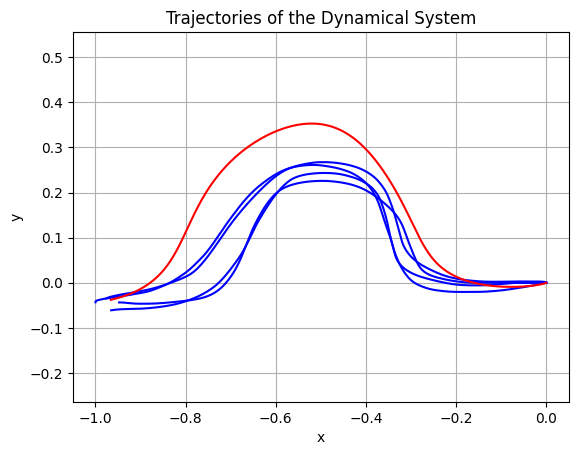

OBTAINING TRAINING DATA
CERTIFICATE TRAINING


<ipython-input-88-861bb51ee1e2>:190: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.unsafe_domain = self.domain[((self.domain >= torch.tensor(self.unsafe_min)) & (self.domain <= torch.tensor(self.unsafe_max))).all(dim=1)]


Epoch 1/30, MSE Loss: 0.36130332946777344
Epoch 1/30, Certificate Loss: -0.23791490495204926
Epoch 2/30, MSE Loss: 0.36014312505722046
Epoch 2/30, Certificate Loss: -5.714240550994873
Epoch 3/30, MSE Loss: 0.35981908440589905
Epoch 3/30, Certificate Loss: -15.878741264343262
Epoch 4/30, MSE Loss: 0.36095577478408813
Epoch 4/30, Certificate Loss: -17.141786575317383
Epoch 5/30, MSE Loss: 0.3613261282444
Epoch 5/30, Certificate Loss: -19.108951568603516
Epoch 6/30, MSE Loss: 0.36092454195022583
Epoch 6/30, Certificate Loss: -17.179611206054688
Epoch 7/30, MSE Loss: 0.358693927526474
Epoch 7/30, Certificate Loss: -19.8402042388916
Epoch 8/30, MSE Loss: 0.35980895161628723
Epoch 8/30, Certificate Loss: -21.525724411010742
Epoch 9/30, MSE Loss: 0.3593386709690094
Epoch 9/30, Certificate Loss: -22.675085067749023
Epoch 10/30, MSE Loss: 0.35983529686927795
Epoch 10/30, Certificate Loss: -23.46200942993164
Epoch 11/30, MSE Loss: 0.35978567600250244
Epoch 11/30, Certificate Loss: -23.9851036071

<ipython-input-88-861bb51ee1e2>:230: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  unsafe_domain =  input_domain[((input_domain >= torch.tensor(self.unsafe_min)) & (input_domain <= torch.tensor(self.unsafe_max))).all(dim=1)]
<ipython-input-88-861bb51ee1e2>:293: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.unsafe_domain_cex = self.domain_cex[((self.domain_cex >= torch.tensor(self.unsafe_min)) & (self.domain_cex <= torch.tensor(self.unsafe_max))).all(dim=1)]


Epoch 1/30, MSE Loss: 0.35295557975769043
Epoch 1/30, Certificate Loss: -24.61467170715332
Epoch 2/30, MSE Loss: 0.35416993498802185
Epoch 2/30, Certificate Loss: -24.076412200927734
Epoch 3/30, MSE Loss: 0.3548605442047119
Epoch 3/30, Certificate Loss: -24.054283142089844
Epoch 4/30, MSE Loss: 0.35430264472961426
Epoch 4/30, Certificate Loss: -24.112049102783203
Epoch 5/30, MSE Loss: 0.35467854142189026
Epoch 5/30, Certificate Loss: -24.526796340942383
Epoch 6/30, MSE Loss: 0.3548542261123657
Epoch 6/30, Certificate Loss: -23.579200744628906
Epoch 7/30, MSE Loss: 0.3543340563774109
Epoch 7/30, Certificate Loss: -22.143667221069336
Epoch 8/30, MSE Loss: 0.35308530926704407
Epoch 8/30, Certificate Loss: -20.501628875732422
Epoch 9/30, MSE Loss: 0.3551240563392639
Epoch 9/30, Certificate Loss: -22.644929885864258
Epoch 10/30, MSE Loss: 0.35413286089897156
Epoch 10/30, Certificate Loss: -22.79446029663086
Epoch 11/30, MSE Loss: 0.3536997437477112
Epoch 11/30, Certificate Loss: -23.4362049

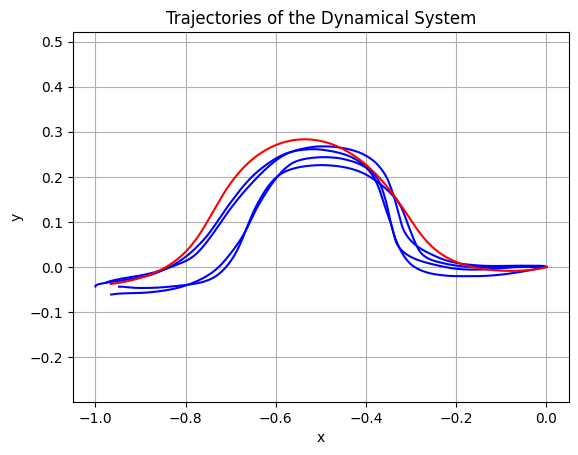

Discretization Parameter: 0.014886458551295736
Lipschitz Constant of Dynamics: 26.640380859375
Lipschitz Constant of Lyapunov: 14.979592323303223
Lipschitz Constant of Barrier: 5.187347412109375
Lipschitz Constant of Lyapunov Gradient: 54.923824310302734
Lipschitz Constant of Barrier Gradient: 58.73583221435547
Lyapunov Verification Failed:
Positivity Failed
Decrease Condition Failed
Barrier Verification Failed:
Initial/Unsafe Condition Failed
Decrease Condition Failed


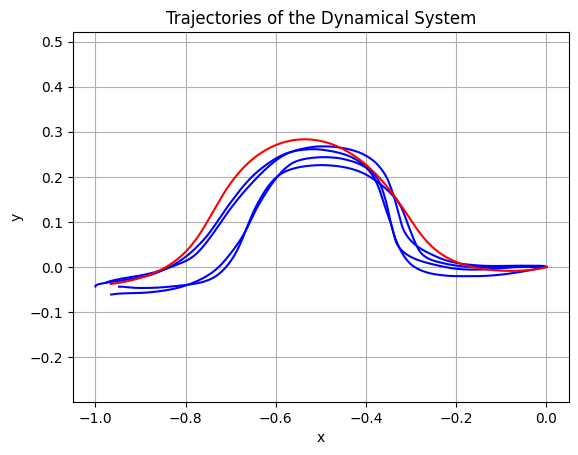

In [ ]:
from common_header import *
import NNModels
import data_new as data
import Loss_Functions_new as Loss_Functions
import opt 
import Plotter
import smt_verification
from dreal import *
import verification


@dataclass
class ConfigFile:
    lasa_name : str = "Worm"
    dataset_type : str = "LASA"

def filter_args(args):
    known_args = ['--lasa_name', '--dataset_type']
    return [arg for arg in args if any(arg.startswith(known) for known in known_args)]

def save_seed(seed, seed_filepath):
    os.makedirs(os.path.dirname(seed_filepath), exist_ok=True)
    with open(seed_filepath, 'w') as file:
        json.dump({'seed': seed}, file)

def load_seed(seed_filepath):
    with open(seed_filepath, 'r') as file:
        seed_data = json.load(file)
    return seed_data['seed']    

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MotionPlanner:
    def __init__(self, args):
        self.args = args
        # Load the configuration file
        file_path = "./config_files/" + self.args.lasa_name + "_config2.json"
        with open(file_path) as file:
            self.config = json.load(file)
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        # self.device = torch.device('cpu')
        #Initialize state dictionaries
        self.model_v_state_dict = None
        self.model_b_state_dict = None
        self.model_f_state_dict = None
        self.optimizer_v_state_dict = None
        self.optimizer_b_state_dict = None
        self.optimizer_f_state_dict = None
        self.scheduler_v_state_dict = None
        self.scheduler_b_state_dict = None
        self.scheduler_f_state_dict = None
        #initialize the learning rate
        self.lr_f = self.config["model_f"]["learning_rate"]
        self.lr_v = self.config["model_v"]["learning_rate"]
        self.lr_b = self.config["model_b"]["learning_rate"]
        self.counterexamples_added = True #Setting the counterexamples flag to true
        self.g = torch.Generator()
        self.g.manual_seed(0)    
        #verification flag
        self.flag_finetune = False
        self.flag_verified = False

    def seed_worker(self,worker_id):
        np.random.seed(0)
        random.seed(0)

    def load_model_states(self):
        if self.model_v_state_dict is not None:
            self.model_v.load_state_dict(self.model_v_state_dict)
        if self.model_b_state_dict is not None:
            self.model_b.load_state_dict(self.model_b_state_dict)
        if self.model_f_state_dict is not None:
            self.model_f.load_state_dict(self.model_f_state_dict)
        if self.optimizer_v_state_dict is not None:
            self.optimizer_v.load_state_dict(self.optimizer_v_state_dict)
        if self.optimizer_b_state_dict is not None:
            self.optimizer_b.load_state_dict(self.optimizer_b_state_dict)
        if self.optimizer_f_state_dict is not None:
            self.optimizer_f.load_state_dict(self.optimizer_f_state_dict)
        if self.scheduler_v_state_dict is not None:
            self.scheduler_v.load_state_dict(self.scheduler_v_state_dict)
        if self.scheduler_b_state_dict is not None:
            self.scheduler_b.load_state_dict(self.scheduler_b_state_dict)
        if self.scheduler_f_state_dict is not None:
            self.scheduler_f.load_state_dict(self.scheduler_f_state_dict)

    def save_model(self, model, optimizer, scheduler, model_path):
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }, model_path)

    def save_all_models(self):
        base_path = os.path.join('models', self.args.lasa_name)
        os.makedirs(base_path, exist_ok=True)  # Ensure the directory exists
        self.save_model(self.model_f, self.optimizer_f, self.scheduler_f, os.path.join(base_path, 'model_f.pth'))
        self.save_model(self.model_v, self.optimizer_v, self.scheduler_v, os.path.join(base_path, 'model_v.pth'))
        self.save_model(self.model_b, self.optimizer_b, self.scheduler_b, os.path.join(base_path, 'model_b.pth'))
      
    def generate_demo_data(self): #Trains data for MSE minimization, learning from demos
        if self.args.dataset_type == 'LASA':
            if self.args.lasa_name == "Angle":
                dataset = lasa.DataSet.Angle
            elif self.args.lasa_name == "Worm":
                dataset = lasa.DataSet.Worm
            elif self.args.lasa_name == "CShape":
                dataset = lasa.DataSet.CShape
            elif self.args.lasa_name == "DoubleBendedLine":
                dataset = lasa.DataSet.DoubleBendedLine
            elif self.args.lasa_name == "GShape":
                dataset = lasa.DataSet.GShape
            elif self.args.lasa_name == "SShape":
                dataset = lasa.DataSet.SShape
            elif self.args.lasa_name == "Leaf_2":
                dataset = lasa.DataSet.Leaf_2
            elif self.args.lasa_name == "Sine":
                dataset = lasa.DataSet.Sine
            else:
                print_error("Invalid LASA Dataset has been choosen")
                raise NotImplementedError
            self.dt = dataset.dt
            self.demos = dataset.demos
            # Divide the data into training and testing
            self.total_demos = len(self.demos)
            self.dim_in = self.demos[0].pos.shape[0]
            train_size = int(5/7 * self.total_demos) # 5/7 datasets are used for training
            train_indices = random.sample(range(self.total_demos), train_size)
            test_indices = list(set(range(self.total_demos)) - set(train_indices))
            self.X_train = np.concatenate([self.demos[i].pos for i in train_indices], axis=1).T
            self.X_test = np.concatenate([self.demos[i].pos for i in test_indices], axis=1).T
            self.y_train = np.concatenate([self.demos[i].vel for i in train_indices], axis=1).T
            self.y_test = np.concatenate([self.demos[i].vel for i in test_indices], axis=1).T 
            self.dim_in = self.X_train.shape[1] #Input dimension used later for constructing neural network
            # Convert to Pytorch Tensors
            self.X_train = torch.tensor(self.X_train, dtype=torch.float32)
            self.X_test = torch.tensor(self.X_test, dtype=torch.float32)
            self.y_train = torch.tensor(self.y_train, dtype=torch.float32)
            self.y_test = torch.tensor(self.y_test, dtype=torch.float32)  
            assert self.X_train.shape[0] == self.y_train.shape[0], "Mismatch in number of samples between X_train and y_train"
            assert self.X_test.shape[0] == self.y_test.shape[0], "Mismatch in number of samples between X_test and y_test" 
            train_dataset = torch.utils.data.TensorDataset(self.X_train, self.y_train)
            test_dataset = torch.utils.data.TensorDataset(self.X_test, self.y_test)
            batch_size = self.config["model_f"]["batch_size"]
            self.train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=self.seed_worker, generator=self.g)
            self.test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=self.seed_worker, generator=self.g)
        else:
            print_error("Non-LASA Dataset has been choosen")
        # Normalise the Trajectories to [-1, 1] #Use the maximum value to normalize and scale the data.
        self.pos_scaling = torch.max(torch.concatenate([abs(self.X_train), abs(self.X_test)]))
        self.vel_scaling = torch.max(torch.concatenate([abs(self.y_train), abs(self.y_test)]))
        self.X_train /= self.pos_scaling
        self.X_test /= self.pos_scaling
        self.y_train /= self.vel_scaling
        self.y_test /= self.vel_scaling
        self.initial_set_center = np.mean([self.demos[i].pos[:,0] for i in range(self.total_demos)], axis=0)/self.pos_scaling

    def generate_domain_data(self):
        if self.flag_finetune == False:
            self.N_domain = self.config["domain"]["N"] #The number of samples we want in the domain region
        else:
            self.N_domain = self.N_domain + self.config["domain"]["additional_N_domain"] 
        self.RANGE = self.config["domain"]["range"] #The number of samples we want in the domain region
        self.domain, _ = data.generateGridData(self.N_domain, self.RANGE) #the domain is limited to [-1,1] due to normalization

        #Generate data for initial set
        self.init_min = (np.min([self.demos[i].pos[:,0] for i in range(self.total_demos)], axis=0)/self.pos_scaling - self.config["init"]["radius"]).reshape(1,2)
        self.init_min = np.where(self.init_min < -1, -1, self.init_min)
        self.init_max = (np.max([self.demos[i].pos[:,0] for i in range(self.total_demos)], axis=0)/self.pos_scaling + self.config["init"]["radius"]).reshape(1,2)
        self.init_max = np.where(self.init_max > 1, 1, self.init_max)

        self.init_domain = self.domain[((self.domain >= torch.tensor(self.init_min)) & (self.domain <= torch.tensor(self.init_max))).all(dim=1)]
        #self.N_init = self.config["init"]["N"]
        #self.init_range = ((np.concatenate((init_min, init_max), axis = 0)).transpose()).tolist()
        #self.init_domain, _ = data.generateGridData(self.N_init, self.init_range)

        #Generate data for unsafe set
        #self.N_unsafe = self.config["unsafe"]["N"]
        self.unsafe = self.config["unsafe"]["range"]
        self.unsafe_min = torch.tensor([self.unsafe[0][0],self.unsafe[1][0]])        
        self.unsafe_max = torch.tensor([self.unsafe[0][1],self.unsafe[1][1]])
        self.unsafe_domain = self.domain[((self.domain >= torch.tensor(self.unsafe_min)) & (self.domain <= torch.tensor(self.unsafe_max))).all(dim=1)]

        #Dataset Generation and Shuffling
        domain_dataset = torch.utils.data.TensorDataset(self.domain)
        init_dataset  = torch.utils.data.TensorDataset(self.init_domain)
        unsafe_dataset  = torch.utils.data.TensorDataset(self.unsafe_domain)
        train_dataset  = torch.utils.data.TensorDataset(self.X_train, self.y_train)

        total_size = len(self.domain) + len(self.init_domain) + len(self.unsafe_domain)

        if self.flag_finetune == False:
           self.batch_size = self.config["model_b"]["batch_size"]
        else:
           self.batch_size *= 1

        domain_batch_size = int(len(self.domain) / total_size * self.batch_size)	
        init_batch_size = max(4, int(len(self.init_domain) / total_size * self.batch_size))
        unsafe_batch_size = max(3, int(len(self.unsafe_domain) / total_size * self.batch_size))

        self.domain_loader = torch.utils.data.DataLoader(domain_dataset, batch_size=domain_batch_size, shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)
        self.init_loader = torch.utils.data.DataLoader(init_dataset, batch_size=init_batch_size,  shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)
        self.unsafe_loader = torch.utils.data.DataLoader(unsafe_dataset, batch_size=unsafe_batch_size, shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)
        self.train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=self.config["model_b"]["batch_size"], shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)

        #Erasing these tensors to reset counterexample generation
        #To be run before the generation of counterexamples for a new set of data!
        if hasattr(self, 'domain_cex'):
            del self.domain_cex
        if hasattr(self, 'input_domain_cex'):
            del self.input_domain_cex 
        if hasattr(self, 'unsafe_cex'):
            del self.unsafe_domain_cex 


    def generate_counterexample_data(self):
        self.load_model_states()     
        N_cex_domain = self.config["counterex"]["N_cex_domain"] #The number of samples we want in the domain region

        input_domain, self.eps = data.generateGridData(N_cex_domain, self.RANGE) #the domain is limited to [-1,1] due to normalization
        init_domain = input_domain[((input_domain >= torch.tensor(self.init_min)) & (input_domain <= torch.tensor(self.init_max))).all(dim=1)]
        unsafe_domain =  input_domain[((input_domain >= torch.tensor(self.unsafe_min)) & (input_domain <= torch.tensor(self.unsafe_max))).all(dim=1)]

        
        counterexamples_domain = verification.verify_domain(self.model_v, self.model_b, self.model_f, 
                                                      input_domain, self.config)
        counterexamples_init = verification.verify_init(self.model_b, init_domain, self.config)
        counterexamples_unsafe = verification.verify_unsafe(self.model_b, unsafe_domain, self.config)
        # if counterexamples_domain.dim() == 1:
        #      counterexamples_domain = counterexamples_domain.unsqueeze(0)

        # if counterexamples_init.dim() == 1:
        #         counterexamples_init = counterexamples_init.unsqueeze(0)     

        # if counterexamples_unsafe.dim() == 1:
        #      counterexamples_unsafe = counterexamples_unsafe.unsqueeze(0)
        add_data_domain = []
        add_data_init = []
        add_data_unsafe = []
        
        for counterexample in counterexamples_domain:
            #for _ in range(self.config["counterex"]["N"]):
                #random_point = counterexample + (torch.rand(counterexample.shape) - 0.5) * 2 * self.config["counterex"]["radius"]
            add_data_domain.append(counterexample)
            
        if len(add_data_domain) > 0:
            add_data_domain = torch.stack(add_data_domain).detach()
        else:
            add_data_domain = None
 
        for counterexample in counterexamples_init:
            #for _ in range(self.config["counterex"]["N"]):
             #   random_point = counterexample + (torch.rand(counterexample.shape) - 0.5) * 2 * self.config["counterex"]["radius"]
                add_data_init.append(counterexample)
        
        if len(add_data_init) > 0:
            add_data_init = torch.stack(add_data_init).detach()
        else:
            add_data_init = None

        for counterexample in counterexamples_unsafe:
            #for _ in range(self.config["counterex"]["N"]):
             #   random_point = counterexample + (torch.rand(counterexample.shape) - 0.5) * 2 * self.config["counterex"]["radius"]
                add_data_unsafe.append(counterexample)

        if len(add_data_unsafe) > 0:
             add_data_unsafe = torch.stack(add_data_unsafe).detach()
        else:
            add_data_unsafe = None

        # Add the counterexamples to the domain data

        if not hasattr(self, 'domain_cex'):
            self.domain_cex = self.domain.clone()
        if not hasattr(self, 'input_domain_cex'):
            self.init_domain_cex = self.init_domain.clone()
        if not hasattr(self, 'unsafe_cex'):
            self.unsafe_domain_cex = self.unsafe_domain.clone()


        if add_data_domain is not None:
             print_info(f"DOMAIN COUNTEREXAMPLES ADDED : {add_data_domain.shape[0]} CEs")
             self.domain_cex = torch.unique(torch.cat([self.domain_cex, add_data_domain], dim=0), dim = 0)
             self.init_domain_cex = self.domain_cex[((self.domain_cex >= torch.tensor(self.init_min)) & (self.domain_cex <= torch.tensor(self.init_max))).all(dim=1)]
             self.unsafe_domain_cex = self.domain_cex[((self.domain_cex >= torch.tensor(self.unsafe_min)) & (self.domain_cex <= torch.tensor(self.unsafe_max))).all(dim=1)]
       
        if add_data_init is not None:
            print_info(f"INIT COUNTEREXAMPLES ADDED : {add_data_init.shape[0]} CEs")
            self.init_domain_cex = torch.unique(torch.cat([self.init_domain_cex, add_data_init], dim=0), dim = 0)
            self.domain_cex = torch.unique(torch.cat([self.domain_cex, add_data_init], dim=0), dim = 0)
        
        if add_data_unsafe is not None:
            print_info(f"UNSAFE COUNTEREXAMPLES ADDED : {add_data_unsafe.shape[0]} CEs")
            self.unsafe_domain_cex = torch.unique(torch.cat([self.unsafe_domain_cex, add_data_unsafe], dim=0), dim =0)
            self.domain_cex = torch.unique(torch.cat([self.domain_cex, add_data_unsafe], dim=0), dim = 0)

        elif add_data_domain is None and add_data_init is None and add_data_unsafe is None:
            print_info("NO COUNTEREXAMPLES ADDED")
            self.counterexamples_added = False

        #Dataset Generation and Shuffling

        domain_dataset = torch.utils.data.TensorDataset(self.domain_cex)
        init_dataset  = torch.utils.data.TensorDataset(self.init_domain_cex)
        unsafe_dataset  = torch.utils.data.TensorDataset(self.unsafe_domain_cex)

        total_size = len(self.domain_cex) + len(self.init_domain_cex) + len(self.unsafe_domain_cex)

        domain_batch_size = int(len(self.domain_cex) / total_size * self.batch_size)	
        init_batch_size = max(4, int(len(self.init_domain_cex) / total_size * self.batch_size))
        unsafe_batch_size = max(3, int(len(self.unsafe_domain_cex) / total_size * self.batch_size))

        self.domain_loader = torch.utils.data.DataLoader(domain_dataset, batch_size=domain_batch_size, shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)
        self.init_loader = torch.utils.data.DataLoader(init_dataset, batch_size=init_batch_size,  shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)
        self.unsafe_loader = torch.utils.data.DataLoader(unsafe_dataset, batch_size=unsafe_batch_size, shuffle=True, num_workers=2, pin_memory=True, worker_init_fn=self.seed_worker, generator=self.g)

    def trainInitialDynamics(self):
        self.hidden_neurons_f = self.config["model_f"]["hidden_neurons"]
        self.hidden_layers_f = self.config["model_f"]["layers"]
        sigmoid_f = NNModels.assignActivationFunction(self.config['model_f']['activation_function'])
        self.hidden_f = [self.hidden_neurons_f] * self.hidden_layers_f
        self.model_f = NNModels.DyanmicsNet(self.dim_in, 
                                            self.hidden_f, 
                                            self.config["model_f"]["clip"], 
                                            sigmoid_f).to(self.device)
        best_mse = np.inf   # init to infinity
        best_weights = None
        history = []
        loss_fn = nn.MSELoss()  # mean square error #TODO: Add Lyapunov, barrier, regularization loss
        self.optimizer_f = torch.optim.Adam( self.model_f.parameters(), lr=self.config["model_f"]["learning_rate"],betas=(0.9, 0.999))
        self.scheduler_f = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer_f, mode='min', factor=self.config["model_f"]["lr_factor"], 
                                                                    patience=self.config["model_f"]["lr_patience"], verbose=True)
        for epoch in range(self.config["model_f"]["epochs_warm"]):
            total_loss = 0
            for batch_idx, (X_batch, y_batch) in enumerate(self.train_loader):
                self.model_f.train()
                # Calculate the loss
                x_val = X_batch.float().to(self.device)
                y_pred = self.model_f(x_val)
                #hyperparameter for l2 regularization
                loss_mse = loss_fn(y_pred, y_batch.float().to(self.device)) #+ DECAY_L2*sum(param.pow(2).sum() for param in self.model_f.parameters())
                #alpha = self.config["hyperparameters"]["alpha"]
                #dec = self.config["model_f"]["init_decay"]
                #loss_lyap = dec*torch.sum(F.leaky_relu(2*x_val*y_pred,alpha))
                loss = loss_mse #+ loss_lyap
                # backward pass
                self.optimizer_f.zero_grad()
                loss.backward()
                self.optimizer_f.step()
                self.model_f.clip_weights()
                total_loss += loss.item()
            # Log the Training Loss
            # wandb.log({"DS_training_loss": total_loss})
            #evaluate accuracy at end of each epoch           
            self.model_f.eval()
            for batch_idx, (X_batch, y_batch) in enumerate(self.test_loader):
                y_pred = self.model_f(X_batch.float().to(self.device))
                mse = loss_fn(y_pred, y_batch.float().to(self.device))
                mse = float(mse)
                history.append(mse)
                if loss < best_mse:
                    best_mse = mse
                    best_weights = copy.deepcopy(self.model_f.state_dict())
                with torch.no_grad():
                    torch.cuda.empty_cache()
        # restore model and return best accuracy
        self.model_f.load_state_dict(best_weights)
        # Store the model state dictionary
        self.model_f_state_dict = best_weights
        self.optimizer_f_state_dict = self.optimizer_f.state_dict()

        print_info("MSE of Initial Estimate of Dynamical System: %.4f" % best_mse)

    def trainCertificate(self):
        if self.config["Barrier"]:
            #Building the Lyapunov Model
            hidden_neurons_v = self.config["model_v"]["hidden_neurons"]
            hidden_layers_v = self.config["model_v"]["layers"]
            hidden_v = [hidden_neurons_v] * hidden_layers_v            
            self.model_v = NNModels.LyapunovNet(
            n_input=self.dim_in,
            hidden_v=hidden_v,
            thresholds=self.config["model_v"]["clip"],
            sigmoid_v=NNModels.assignActivationFunction(self.config['model_v']['activation_function'])).to(self.device)
            #Optimizer and Scheduler for Lyapunov Function
            if self.flag_finetune == False:
                self.optimizer_v = torch.optim.Adam(self.model_v.parameters(), lr = self.config["model_v"]["learning_rate"], weight_decay = self.config["hyperparameters"]["reg_v"])
                warmup_scheduler_v = opt.WarmUpLR(self.optimizer_v, self.config["model_v"]["warmup"], self.config["model_v"]["learning_rate"])
            else:
                self.optimizer_v = torch.optim.Adam(self.model_v.parameters(), lr = self.config["model_v"]["learning_rate_ft"], weight_decay = self.config["hyperparameters"]["reg_v"])
                warmup_scheduler_v = opt.WarmUpLR(self.optimizer_v, self.config["model_v"]["warmup"], self.config["model_v"]["learning_rate_ft"])
                
            self.scheduler_v = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer_v, mode = 'min', factor = self.config["model_v"]["lr_factor"],
                                                                    patience = self.config["model_v"]["lr_patience"], verbose = True)
            
            #Building the Barrier Model
            hidden_neurons_b = self.config["model_b"]["hidden_neurons"]
            hidden_layers_b = self.config["model_b"]["layers"]
            hidden_b = [hidden_neurons_b] * hidden_layers_b
            self.model_b = NNModels.BarrierNet(
            n_input=self.dim_in,
            hidden_b=hidden_b,
            thresholds = self.config["model_b"]["clip"],
            sigmoid_b=NNModels.assignActivationFunction(self.config['model_b']['activation_function'])).to(self.device)
            #Optimizer and Scheduler for Barrier Function
            if self.flag_finetune == False:
                self.optimizer_b = torch.optim.Adam(self.model_b.parameters(), lr = self.config["model_b"]["learning_rate"], weight_decay = self.config["hyperparameters"]["reg_bar"])
                warmup_scheduler_b = opt.WarmUpLR(self.optimizer_b, self.config["model_b"]["warmup"], self.config["model_b"]["learning_rate"])
            else:
                self.optimizer_b = torch.optim.Adam(self.model_b.parameters(), lr = self.config["model_b"]["learning_rate_ft"], weight_decay = self.config["hyperparameters"]["reg_bar"])
                warmup_scheduler_b = opt.WarmUpLR(self.optimizer_b, self.config["model_b"]["warmup"], self.config["model_b"]["learning_rate_ft"])

            
            self.scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer_b, mode = 'min', factor = self.config["model_b"]["lr_factor"],
                                                                    patience = self.config["model_b"]["lr_patience"], verbose = True)

            # Load the stored model state dictionary if available
            self.load_model_states()        
            # Start Training
            start = timeit.default_timer() 
            if self.flag_finetune == False:
                 max_iter = self.config["hyperparameters"]["max_iters"]
            else:
                max_iter = self.config["hyperparameters"]["max_iters_ft"]

            for epoch in range(max_iter):
                cert_loss = 0
                dyn_loss = 0
                for batches in itertools.zip_longest(self.domain_loader, self.train_loader, self.init_loader, self.unsafe_loader, fillvalue=None):
                    self.optimizer_f.zero_grad()
                    self.optimizer_v.zero_grad()
                    self.optimizer_b.zero_grad()
                    if batches[0] is not None:
                        input_domain = batches[0][0].to(self.device)
                        loss_domain = Loss_Functions.loss_function_domain(self.model_v, self.model_b, self.model_f, input_domain, self.config)
                        loss_domain.backward(retain_graph=True)
                    else:
                        loss_domain = torch.tensor(0.0, requires_grad = True)
                    if batches[1] is not None:
                        input_train = batches[1][0].to(self.device)
                        output_train = batches[1][1].to(self.device)
                        loss_train = Loss_Functions.loss_function_dyn(self.model_f, input_train, output_train, self.config)
                        loss_train.backward(retain_graph=True)
                    else:
                        loss_train = torch.tensor(0.0, requires_grad = True)

                    if batches[2] is not None:
                        input_init = batches[2][0].to(self.device)
                        loss_init = Loss_Functions.loss_function_init( self.model_b, input_init, self.config)
                        loss_init.backward(retain_graph=True)
                    else:
                        loss_init = torch.tensor(0.0, requires_grad = True)

                    if batches[3] is not None:
                        input_unsafe = batches[3][0].to(self.device)
                        loss_unsafe = Loss_Functions.loss_function_unsafe(self.model_b, input_unsafe, self.config)
                        loss_unsafe.backward(retain_graph=True)
                    else:
                        loss_unsafe = torch.tensor(0.0, requires_grad = True)

                    torch.nn.utils.clip_grad_norm_(self.model_f.parameters(), max_norm=1.0)
                    torch.nn.utils.clip_grad_norm_(self.model_v.parameters(), max_norm=1.0)
                    torch.nn.utils.clip_grad_norm_(self.model_b.parameters(), max_norm=1.0)

                    self.optimizer_f.step()
                    self.optimizer_v.step() 
                    self.optimizer_b.step()
                    
                    # Calculate average training loss for the epoch
                    cert_loss += loss_domain + loss_init + loss_unsafe
                    dyn_loss += loss_train

                    avg_loss_f = dyn_loss / len(self.train_loader)
                    # Step the scheduler with training loss
                    self.scheduler_f.step(avg_loss_f)
                    # Update learning rate with warm-up
                    if epoch < self.config["model_v"]["warmup"]:
                        warmup_scheduler_v.step()
                    else:
                        avg_loss_cert = cert_loss/len(self.domain_loader)
                        self.scheduler_v.step(avg_loss_cert)

                    if epoch < self.config["model_b"]["warmup"]:
                        warmup_scheduler_b.step()
                    else:
                        avg_loss_cert = cert_loss/len(self.domain_loader)
                        self.scheduler_b.step(avg_loss_cert)

                    self.model_f.clip_weights()
                    self.model_v.clip_weights()
                    self.model_b.clip_weights()
                
                # Log the training loss
                decay=self.config["hyperparameters"]["decay_mse"]
                print(f"Epoch {epoch + 1}/{max_iter}, MSE Loss: {dyn_loss.item()/decay}")
                print(f"Epoch {epoch + 1}/{max_iter}, Certificate Loss: {cert_loss.item()}")

            # Save the recent versions of model_v and model_b in memory
            self.model_v_state_dict = self.model_v.state_dict()
            self.model_b_state_dict = self.model_b.state_dict()
            self.model_f_state_dict = self.model_f.state_dict()
            self.final_mse_loss = dyn_loss.item()
            self.final_cert_loss = cert_loss.item()

    def verifyCertificate(self):
        weights_f = [params.detach() for name, params in self.model_f.named_parameters()
                     if 'weight' in name]
        weights_v = [params.detach() for name, params in self.model_v.named_parameters()
                     if 'weight' in name]
        weights_b = [params.detach() for name, params in self.model_b.named_parameters()
                     if 'weight' in name]

        self.lip_f = verification.lipschitz_network(weights_f)
        self.lip_v = verification.lipschitz_network(weights_v)
        self.lip_b = verification.lipschitz_network(weights_b)

        #lipschitz constant for derivatives
        self.lip_dv = self.lip_f + verification.lipschitz_gradient(weights_v)
        self.lip_db = self.lip_f + verification.lipschitz_gradient(weights_b)
        print_info(f"Discretization Parameter: {self.eps}")
        print_info(f"Lipschitz Constant of Dynamics: {self.lip_f}")
        print_info(f"Lipschitz Constant of Lyapunov: {self.lip_v}")
        print_info(f"Lipschitz Constant of Barrier: {self.lip_b}")
        print_info(f"Lipschitz Constant of Lyapunov Gradient: {self.lip_dv}")
        print_info(f"Lipschitz Constant of Barrier Gradient: {self.lip_db}")
        #Lyapunov conditions to be checked
        self.pos_verify = False
        self.grad_verify = False
        self.lyap_verify = False
        if self.lip_v*self.eps + self.config["counterex"]["pos_tol"] <= 0:
            self.pos_verify = True
        if self.lip_dv*self.eps + self.config["counterex"]["lyap_tol"] <= 0:
            self.grad_verify = True
        if self.pos_verify and self.grad_verify:
            self.lyap_verify = True

        #Barrier conditions to be checked 
        self.inun_verify = False
        self.dec_verify = False
        self.bar_verify = False
        if self.lip_b*self.eps + self.config["counterex"]["inun_tol"] <= 0:
            self.inun_verify = True
        if self.lip_db*self.eps + self.config["counterex"]["bar_tol"] <= 0:
            self.dec_verify = True
        if self.inun_verify and self.dec_verify:
            self.bar_verify = True

        if not self.lyap_verify:
            print_info("Lyapunov Verification Failed:")
            if not self.pos_verify:
                print_info("Positivity Failed")
            if not self.grad_verify:
                print_info("Decrease Condition Failed")

        if not self.bar_verify:
            print_info("Barrier Verification Failed:")
            if not self.pos_verify:
                print_info("Initial/Unsafe Condition Failed")
            if not self.grad_verify:
                print_info("Decrease Condition Failed")

        if self.lyap_verify and self.bar_verify:
            print_success("Formal Verification Successful!")
            self.flag_verified = True
        else:
            self.flag_finetune = True
            
    def prune_models(self, prune_amount):
        for name, module in self.model_v.named_modules():
            if isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=prune_amount)
                prune.remove(module, 'weight')  # Remove the pruning reparameterization
        for name, module in self.model_b.named_modules():
            if isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=prune_amount)
                prune.remove(module, 'weight')
        for name, module in self.model_f.named_modules():           
            if isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=prune_amount)
                prune.remove(module, 'weight')

if __name__ == "__main__":
    # Settings Seeds for Reproducibility
    filtered_args = filter_args(sys.argv[1:])
    args = pyrallis.parse(ConfigFile, args=filtered_args)
    seed_filepath = f'seeds/{args.lasa_name}_seed.json'
    #Check if the seed file exists
    try:
       seed = load_seed(seed_filepath)
    except FileNotFoundError:
       seed = 0  # seed value
    #seed = random.randint(0, 100)
    set_seed(0)
    mp = MotionPlanner(args)
    print_info("OBTAINING DEMO DATA")
    mp.generate_demo_data()
    print_info("DYNAMICAL SYSTEM TRAINING")
    mp.trainInitialDynamics()
    Plotter.initialDSPlot(mp.model_f, mp.X_train, mp.initial_set_center, mp.dt)
    print_info("OBTAINING TRAINING DATA")
    mp.generate_domain_data()
    iters = 1
    #while not mp.flag_verified and iters <= 20: 
    print_info("CERTIFICATE TRAINING")
    mp.trainCertificate()
    trial = 1
    lr_inc = mp.config["counterex"]["lr_increment_factor"]
    while trial < 100:
        print_info("ADDING COUNTEREXAMPLES")
        mp.generate_counterexample_data()
        if mp.counterexamples_added:
            mp.trainCertificate()
            trial += 1      
            for param_group in mp.optimizer_f.param_groups:
                param_group['lr'] *= lr_inc
            for param_group in mp.optimizer_v.param_groups:
                param_group['lr'] *= lr_inc
            for param_group in mp.optimizer_b.param_groups:
                param_group['lr'] *= lr_inc
        else:
            print_info("SAMPLING-BASED VERIFICATION COMPLETE")
            for param_group in mp.optimizer_f.param_groups:
                param_group['lr'] = mp.lr_f
            for param_group in mp.optimizer_v.param_groups:
                param_group['lr'] = mp.lr_v
            for param_group in mp.optimizer_b.param_groups:
                param_group['lr'] = mp.lr_b
            Plotter.initialDSPlot(mp.model_f, mp.X_train, mp.initial_set_center, mp.dt)
            break
    if trial == 100:
        print_error("MAXIMUM TRIALS EXCEEDED... SAMPLING VERIFICATION FAILED")
        
    mp.verifyCertificate()
        # if not mp.flag_verified:
        #     print_info("RETRAINING... ADDING NEW DATA")
        #     mp.generate_domain_data()    
        #     print_info(f"N_domain value: {mp.N_domain}")
        #     # print_info("PRUNE THE MODELS FOR FINE-TUNING")
        #     # mp.prune_models(0.2)
        #     mp.counterexamples_added = True
        #     mp.flag_finetune = True
        #     iters +=1
        # else:
        #     print_info("VERIFICATION SUCCESSFUL")
        #     break    
    save_seed(seed,seed_filepath) 
    Plotter.initialDSPlot(mp.model_f, mp.X_train, mp.initial_set_center, mp.dt)
    mp.save_all_models()
 